In [2]:
pip install -U transformers

In [3]:
pip install -U accelerate

In [4]:
pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 3.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5
    Uninstalling datasets-4.8.5:
      Successfully uninstalled datasets-4.8.5


In [5]:
pip install -U bertviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 1.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 58.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 68.2 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 8.3 MB/s eta 0:00:00


In [6]:
pip install -U umap-learn

In [7]:
pip install seaborn --upgrade

In [8]:
import pandas as pd

In [9]:
df= pd.read_csv("https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/refs/heads/master/twitter_multi_class_sentiment.csv")

In [10]:
df

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness
15996,i am now turning and i feel pathetic that i am...,0,sadness
15997,i feel strong and good overall,1,joy
15998,i feel like this was such a rude comment and i...,3,anger


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        16000 non-null  object
 1   label       16000 non-null  int64 
 2   label_name  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB


In [12]:
df.shape

(16000, 3)

In [13]:
df.isnull().sum()

,0
text,0
label,0
label_name,0


In [14]:
df.describe()

,label
count,16000.000000
mean,1.565937
std,1.501430
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [15]:
df['label'].value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


In [16]:
df['label_name'].value_counts()

,count
label_name,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


# Data Analysis

In [17]:
import matplotlib.pyplot as plt

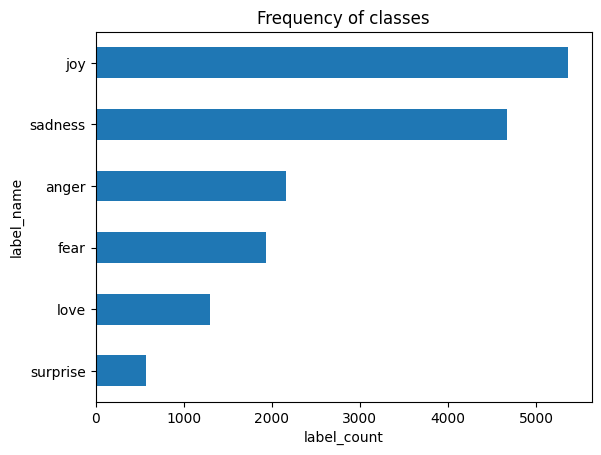

In [18]:
label_counts = df['label_name'].value_counts(ascending=True)
label_counts.plot.barh()
plt.title('Frequency of classes')
plt.xlabel('label_count')
plt.show()

In [19]:
df["Words per Tweet"] = df['text'].str.split().apply(len)
df


,text,label,label_name,Words per Tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness,24
15996,i am now turning and i feel pathetic that i am...,0,sadness,20
15997,i feel strong and good overall,1,joy,6
15998,i feel like this was such a rude comment and i...,3,anger,14


<Axes: title={'center': 'Words per Tweet'}, xlabel='label_name'>

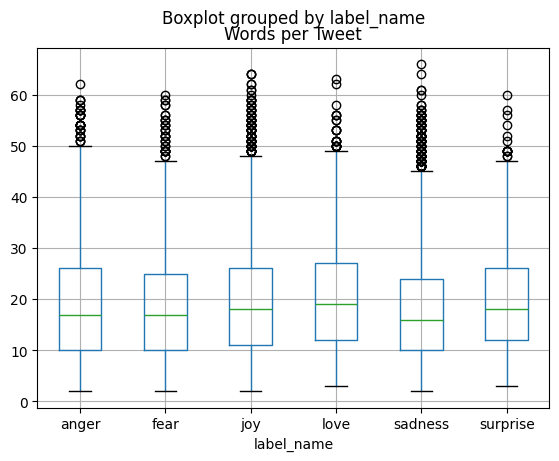

In [20]:
df.boxplot("Words per Tweet",by='label_name') # esme bta rhe loggo ne jo tweet kiya emotions ko lekr bo kitne words me /kitne 50% me log jyada aye hai

# Text Tokenizer

In [21]:
from transformers import AutoTokenizer 
model="bert-base-uncased"
tokenizer=AutoTokenizer.from_pretrained(model)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
text=" i love Machine learning! i hate misguide people!!"
c=tokenizer(text)


{'input_ids': [101, 1045, 2293, 3698, 4083, 999, 1045, 5223, 28616, 28582, 2111, 999, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
len(tokenizer.vocab), tokenizer.vocab_size ,tokenizer.model_max_length

(30522, 30522, 512)

In [ ]:
# Data Loader and train_test_split

In [ ]:
df

,text,label,label_name,Words per Tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness,24
15996,i am now turning and i feel pathetic that i am...,0,sadness,20
15997,i feel strong and good overall,1,joy,6
15998,i feel like this was such a rude comment and i...,3,anger,14


In [ ]:
from sklearn.model_selection import train_test_split
train,test=train_test_split(df,test_size=0.3,stratify=df['label_name'])
test ,validation=train_test_split(test,test_size=1/3,stratify=test['label_name'])
train.shape,test.shape,validation.shape

((11200, 4), (3200, 4), (1600, 4))

In [ ]:
from datasets import Dataset ,DatasetDict
dataset=DatasetDict(
    {'train':Dataset.from_pandas(train,preserve_index=False),
    'test':Dataset.from_pandas(test,preserve_index=False),
    'validation':Dataset.from_pandas(validation,preserve_index=False)
    }
)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 1600
    })
})

Aap is code mein Hugging Face ki Dataset aur DatasetDict classes ka use kar rahe ho. Iska main purpose hai apne Pandas DataFrames (train, test, validation) ko Hugging Face Dataset format mein convert karna, taaki BERT model ke saath aasani se use kar sako.

## Tokenization of emotion/sentiment data

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 3200
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'Words per Tweet'],
        num_rows: 1600
    })
})

In [ ]:
dataset['train'][0]

{'text': 'i feel it would be pleasant to have a cigarette there is a sort of deep rooted memory of enjoying sucking that carcenogenic smoke into my lungs but i believe that feeling of pleasantness is an illusion',
 'label': 1,
 'label_name': 'joy',
 'Words per Tweet': 37}

In [ ]:
def tokenize(batch):
    temp = tokenizer(batch['text'],padding=True,truncation=True)
    return temp

print(tokenize(dataset['train'][:2]))

{'input_ids': [[101, 1045, 2514, 2009, 2052, 2022, 8242, 2000, 2031, 1037, 9907, 2045, 2003, 1037, 4066, 1997, 2784, 15685, 3638, 1997, 9107, 13475, 2008, 2482, 27524, 24278, 5610, 2046, 2026, 8948, 2021, 1045, 2903, 2008, 3110, 1997, 8242, 2791, 2003, 2019, 12492, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 5228, 2026, 5936, 2008, 25093, 12969, 2018, 2428, 6430, 2000, 1996, 2391, 2008, 2016, 2085, 2823, 3594, 13675, 4904, 8376, 1998, 2006, 1037, 2204, 2154, 1996, 3460, 4081, 16928, 7242, 1998, 2056, 2002, 2052, 3967, 2256, 2334, 16928, 19294, 1998, 2057, 2253, 2006, 2256, 12831, 2126, 3110, 2738, 9841, 14644, 6528, 2098, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [ ]:
emotion_encoded = dataset.map(tokenize,batched=True,batch_size=None)
emotion_encoded

In [ ]:
# label2id,id2label
label2id={x['label_name']:x['label'] for x in dataset['train']}
id2label={v:k for k,v in label2id.items()}
label2id,id2label

({'joy': 1, 'sadness': 0, 'surprise': 5, 'love': 2, 'fear': 4, 'anger': 3},
 {1: 'joy', 0: 'sadness', 5: 'surprise', 2: 'love', 4: 'fear', 3: 'anger'})

# Model Building

In [ ]:
from transformers import AutoModel
import torch

In [ ]:
model_1=AutoModel.from_pretrained(model)

In [ ]:
model_1

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
model_1.config.architectures

['BertForMaskedLM']

# ADd classification head

In [ ]:
from transformers import AutoModelForSequenceClassification,AutoConfig

In [ ]:
num_labels=len(label2id)
num_labels
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config=AutoConfig.from_pretrained(model,id2label=id2label,label2id=label2id)


In [ ]:
models= AutoModelForSequenceClassification.from_pretrained(model,config=config).to(device)
models

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

# Training Arguments

In [ ]:
from transformers import TrainingArguments
batch_size=64
training_dir="bert_base_train_dir"
training_args=TrainingArguments(
    output_dir=training_dir,
    # overwrite_output_dir=True,
    eval_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=2,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    disable_tqdm=False
)

# Compute metrics


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
def compute_metrics(pred):
    labels=pred.label_ids
    preds=pred.predictions.argmax(-1)

    f1=f1_score(labels,preds,average='weighted')
    acc=accuracy_score(labels,preds)
    return {'f1':f1,'accuracy':acc}

## Building Model and Trainer

In [ ]:
from transformers import Trainer
trainer = Trainer(
    model=models,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=emotion_encoded['train'],
    eval_dataset=emotion_encoded['validation'],
    processing_class=tokenizer
)


In [ ]:
trainer.train()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,No log,0.459278,0.848294,0.856875
2,No log,0.300362,0.897774,0.897500


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=350, training_loss=0.6726783534458706, metrics={'train_runtime': 20628.9498, 'train_samples_per_second': 1.086, 'train_steps_per_second': 0.017, 'total_flos': 1001502421516800.0, 'train_loss': 0.6726783534458706, 'epoch': 2.0})

# Model Evaluation

In [ ]:
preds_output=trainer.predict((emotion_encoded['test']))

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
preds_output.metrics

{'test_loss': 0.31406643986701965,
 'test_f1': 0.8955330173461753,
 'test_accuracy': 0.895625,
 'test_runtime': 741.3395,
 'test_samples_per_second': 4.317,
 'test_steps_per_second': 0.067}

In [ ]:
preds_output.predictions

array([[-0.7948995 , -1.1448635 , -0.7436068 ,  3.4827874 ,  0.02559209,
        -1.3956771 ],
       [-1.0298805 , -1.2186168 , -0.55609107, -0.3796438 ,  2.6180801 ,
         2.0644374 ],
       [-0.8813998 ,  3.9144015 , -0.11428716, -1.3293773 , -1.3697914 ,
        -0.61962795],
       ...,
       [-1.4579654 , -0.5376637 , -0.38642797, -0.23474184,  1.9881475 ,
         2.603438  ],
       [-0.34283736, -1.1390508 , -0.5034679 ,  3.5738664 , -0.67364454,
        -1.0433793 ],
       [ 4.020052  , -0.9186986 , -0.93775177, -0.91598356, -0.8290842 ,
        -1.0303597 ]], dtype=float32)

In [ ]:
import numpy as np

In [ ]:
y_pred=np.argmax(preds_output.predictions,axis=1)
y_true=emotion_encoded['test'][:]['label']
y_pred

array([3, 4, 1, ..., 5, 3, 0])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       933
           1       0.91      0.92      0.91      1072
           2       0.76      0.74      0.75       261
           3       0.90      0.92      0.91       432
           4       0.90      0.82      0.86       387
           5       0.69      0.80      0.74       115

    accuracy                           0.90      3200
   macro avg       0.85      0.86      0.85      3200
weighted avg       0.90      0.90      0.90      3200



In [ ]:
label2id

{'joy': 1, 'sadness': 0, 'surprise': 5, 'love': 2, 'fear': 4, 'anger': 3}

# Plot confusion metrix

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [ ]:
cm=confusion_matrix(y_true,y_pred)
cm

array([[887,  18,   2,  12,  13,   1],
       [ 22, 981,  53,   3,   5,   8],
       [  6,  57, 192,   3,   1,   2],
       [ 22,   8,   1, 396,   5,   0],
       [  9,   3,   2,  24, 318,  31],
       [  3,   7,   1,   0,  12,  92]])

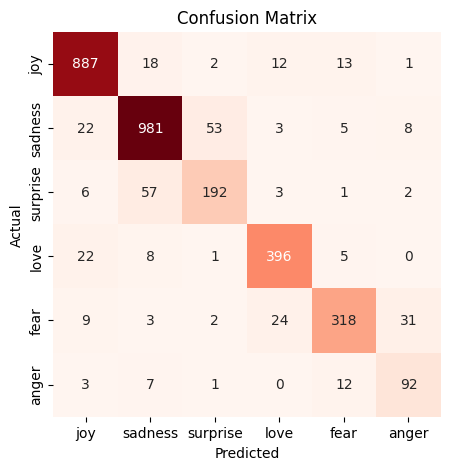

In [ ]:
plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,xticklabels=label2id.keys(),yticklabels=label2id.keys(),fmt='d',cbar=False,cmap='Reds')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

# Built prediction Function and Store Model

In [ ]:
text="i am super happy today.i got it done.Finally!!"
input_encoder=tokenizer(text,return_tensors='pt').to(device)
with torch.no_grad():
  outputs=models(**input_encoder)

logits=outputs.logits


In [ ]:
logits

tensor([[-0.9584,  3.9078,  0.2053, -1.3633, -1.6606, -0.9629]])

In [ ]:
pred=torch.argmax(logits,dim=1).item()
pred,id2label[pred]


(1, 'joy')

# Make function

In [ ]:
def get_prediction(text):
  input_encoder=tokenizer(text,return_tensors='pt').to(device)
  with torch.no_grad():
    outputs=models(**input_encoder)

  logits=outputs.logits
  pred=torch.argmax(logits,dim=1).item()
  return id2label[pred]


get_prediction(text)



'joy'

# Save Model

In [ ]:
trainer.save_model("bert-base-uncased-sentiment-model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# upload model and make prediction

In [ ]:
from transformers import pipeline
model1="bert-base-uncased-sentiment-model"
classifier=pipeline("text-classification",model=model1)
classifier(text)



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'joy', 'score': 0.953300416469574}]